In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

data = pd.read_csv("Bank_Personal_Loan_Modelling.csv")
print("✅ Data Loaded Successfully!\n")
print(data.head())


✅ Data Loaded Successfully!

   ID  Age  Experience  Income  ZIP Code  Family CCAvg  Education  Mortgage  \
0   1   25           1      49     91107       4  1/60          1         0   
1   2   45          19      34     90089       3  1/50          1         0   
2   3   39          15      11     94720       1  1/00          1         0   
3   4   35           9     100     94112       1  2/70          2         0   
4   5   35           8      45     91330       4  1/00          2         0   

   Personal Loan  Securities Account  CD Account  Online  CreditCard  
0              0                   1           0       0           0  
1              0                   1           0       0           0  
2              0                   0           0       0           0  
3              0                   0           0       0           0  
4              0                   0           0       0           1  


In [3]:
# Check for missing values
print("\nMissing Values:\n", data.isnull().sum())

# Drop unnecessary columns if present (like ID or ZIP Code)
data = data.drop(['ID'], axis=1)
data = data.drop(['ZIP Code'], axis=1)
data = data.drop(['CCAvg'], axis=1)




Missing Values:
 ID                    0
Age                   0
Experience            0
Income                0
ZIP Code              0
Family                0
CCAvg                 0
Education             0
Mortgage              0
Personal Loan         0
Securities Account    0
CD Account            0
Online                0
CreditCard            0
dtype: int64


In [4]:
# Define features and target
X = data.drop(['Personal Loan'], axis=1)  # input features
y = data['Personal Loan']                 # target variable (0 or 1)


In [5]:
# Scale numeric features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(X_scaled)

[[-1.77441684 -1.66607847 -0.53822878 ... -0.25354028 -1.21661774
  -0.64531434]
 [-0.02952359 -0.09633022 -0.8641094  ... -0.25354028 -1.21661774
  -0.64531434]
 [-0.55299157 -0.44516316 -1.36379301 ... -0.25354028 -1.21661774
  -0.64531434]
 ...
 [ 1.54088033  1.64783451 -1.08136314 ... -0.25354028 -1.21661774
  -0.64531434]
 [ 1.71536965  1.73504275 -0.53822878 ... -0.25354028  0.82195086
  -0.64531434]
 [-1.51268285 -1.40445376  0.20043396 ... -0.25354028  0.82195086
   1.54963239]]


In [18]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.25, random_state=42
)


In [20]:
# Train logistic regression model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [21]:
# Predictions
y_pred = model.predict(X_test)

In [22]:
# Evaluation
print("🎯 Accuracy:", round(accuracy_score(y_test, y_pred) * 100, 2), "%")
print("\n📊 Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\n🧾 Classification Report:\n", classification_report(y_test, y_pred))

🎯 Accuracy: 95.04 %

📊 Confusion Matrix:
 [[1103   13]
 [  49   85]]

🧾 Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.99      0.97      1116
           1       0.87      0.63      0.73       134

    accuracy                           0.95      1250
   macro avg       0.91      0.81      0.85      1250
weighted avg       0.95      0.95      0.95      1250



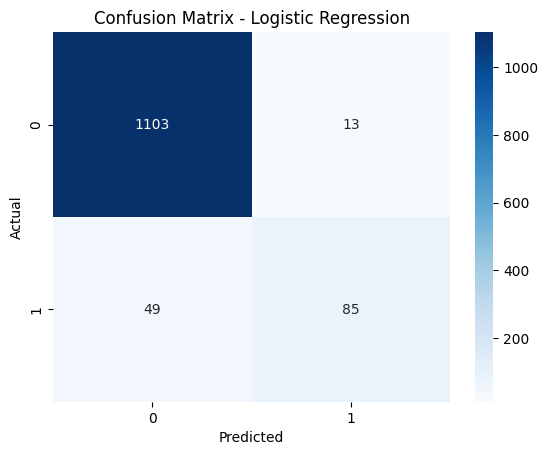

In [23]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()